In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"//content//ShopData.csv")

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data =df.iloc[:,3:5].values #means all rows,3:5 means col 3 & 4
data

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [6]:
sil_scores = []
scre = 0
kn = 2

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    labels = kmeans.fit_predict(data)

    sil_score = silhouette_score(data, labels)

    if scre < sil_score:
        scre = sil_score
        kn = k

    sil_scores.append(sil_score)

    print(f"Silhouette Score(k={k}): {sil_score}")

print(kn, ':', scre)

Silhouette Score(k=2): 0.39465548731848604
Silhouette Score(k=3): 0.46761358158775435
Silhouette Score(k=4): 0.4937945814354117
Silhouette Score(k=5): 0.553931997444648
Silhouette Score(k=6): 0.4561972992633143
Silhouette Score(k=7): 0.5264283703685728
Silhouette Score(k=8): 0.45554947603730966
5 : 0.553931997444648


Text(0, 0.5, 'Silhouette Score')

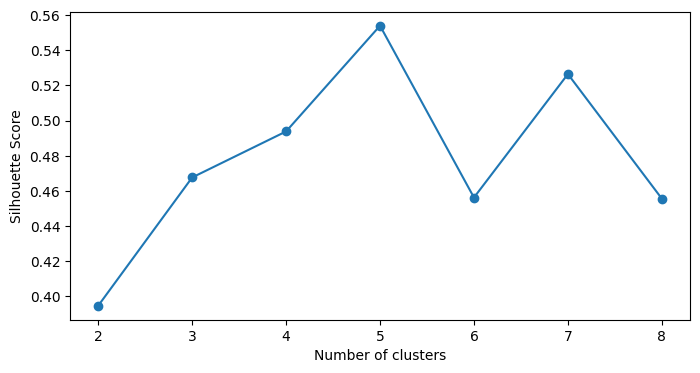

In [7]:
frame = pd.DataFrame({'Cluster':range(2,9), 'Silhouette Score':sil_scores})
plt.figure(figsize=(8,4))
plt.plot(frame['Cluster'], frame['Silhouette Score'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')

In [8]:
kmns =KMeans(n_clusters=kn,init='k-means++',max_iter=300,random_state=5)
y_kmeans = kmns.fit_predict(data)
print(y_kmeans)

kmns.cluster_centers_

[0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0
 4 0 4 0 4 0 1 0 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 3 2 3 1 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 1 3 2 3 2 3
 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2
 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3]


array([[26.30434783, 20.91304348],
       [55.0875    , 49.7125    ],
       [87.75      , 17.58333333],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636]])

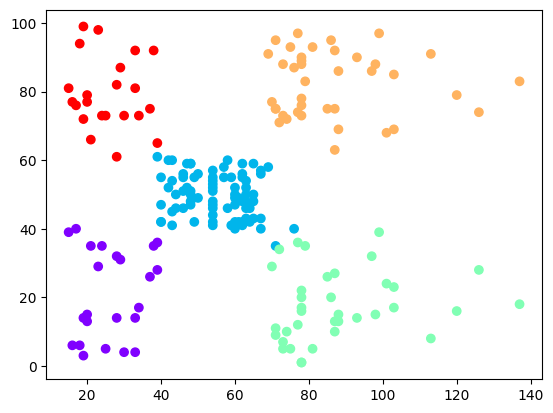

In [9]:
plt.scatter(data[:,0], data[:,1], c= y_kmeans,cmap='rainbow');

In [10]:
import seaborn as sns

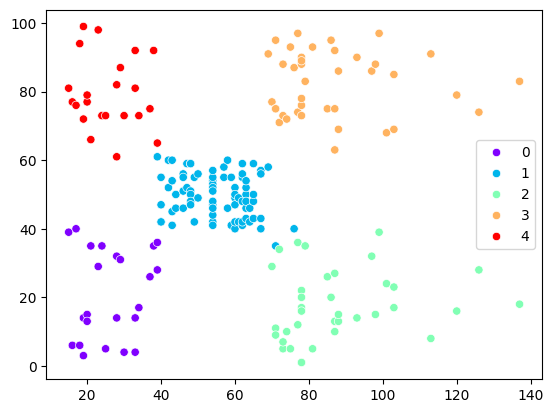

In [11]:
sns.scatterplot(x=data[:,0], y=data[:,1], hue=y_kmeans, palette='rainbow')
plt.show()

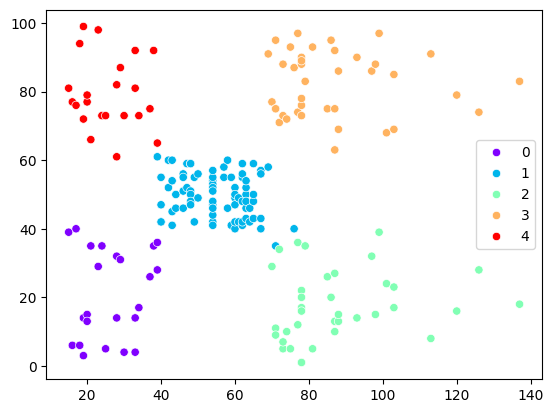

In [12]:
sns.scatterplot(x=data[:, 0], y=data[:, 1], hue=y_kmeans, palette='rainbow')
plt.show()

In [13]:
clustdf = pd.DataFrame({**df,'Cluster': y_kmeans})
clustdf.sort_values(by='Cluster')

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,0
2,3,Female,20,16,6,0
6,7,Female,35,18,6,0
4,5,Female,31,17,40,0
12,13,Female,58,20,15,0
...,...,...,...,...,...,...
27,28,Male,35,28,61,4
19,20,Female,35,23,98,4
17,18,Male,20,21,66,4
21,22,Male,25,24,73,4


In [14]:
SSE = []
clusMn = 2
clusMx = 11
for cluster in range(clusMn,clusMx):
    kmeans = KMeans(n_clusters = cluster, init='k-means++')
    kmeans.fit(data)
    SSE.append(kmeans.inertia_)

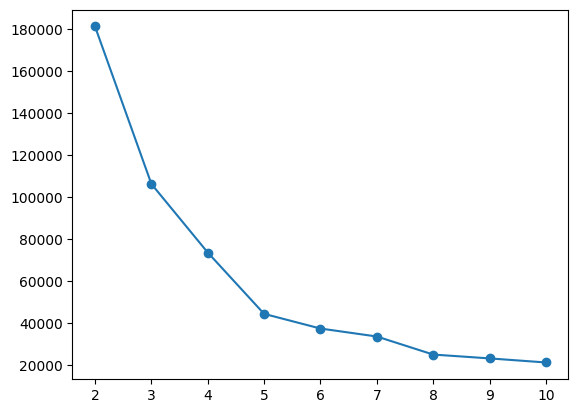

In [15]:
frame = pd.DataFrame({'Cluster':range(clusMn,clusMx), 'SSE':SSE})
plt.plot(frame['Cluster'], frame['SSE'], marker='o')